# Driving School Installs Prediction (ARIMA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from utils import check_stationarity

warnings.filterwarnings("ignore")

## Hyperparameters & Config

In [2]:
DATA_CSV_FILE = "../../../data/ds_data_clean.csv"
TARGET_COL = "Daily User Installs"
TRAIN_RATIO = 0.8

## Loading Data

In [3]:
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df["Is Weekend"] = (df["Date"].dt.dayofweek >= 5).astype(int)  # 5=Sat, 6=Sun
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

# Ensure data is univariate for basic ARIMA
series = df[TARGET_COL]
series.head()

Date
2019-09-02    2
2019-09-03    1
2019-09-04    2
2019-09-05    3
2019-09-06    6
Name: Daily User Installs, dtype: int64

## Stationarity Check

In [4]:
check_stationarity(series, title=TARGET_COL)

--- Stationarity Tests for Daily User Installs ---
ADF Statistic: -3.9122
ADF p-value: 0.0019
ADF Critical Values:
   1%: -3.4332
   5%: -2.8628
   10%: -2.5674
KPSS Statistic: 0.5268
KPSS p-value: 0.0356
KPSS Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: The series is likely non-stationary.


## Preprocessing and Temporal Split

In [5]:
train_size = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:train_size]
test_df  = df.iloc[train_size:]

train = train_df[TARGET_COL]
test  = test_df[TARGET_COL]

print(f"Train: {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train)} days)")
print(f"Test:  {test_df.index[0].date()} → {test_df.index[-1].date()}  ({len(test)} days)")

Train: 2019-09-02 → 2024-09-24  (1850 days)
Test:  2024-09-25 → 2025-12-31  (463 days)


## Auto-ARIMA to Find Optimal Parameters (p, d, q)

In [6]:
model_auto = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.62 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=41581.263, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=41583.202, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=41583.197, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=41579.264, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=41575.965, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=41570.133, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=41578.572, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=41570.032, Time=0.16 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=41578.002, Time=0.04 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=41472.810, Time=0.31 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=41544.449, Time=0.08 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=41474.466, Time=0.50 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(3,1,2)(0,0,0)[0] interce

## Fit Final ARIMA Model

In [7]:
p, d, q = model_auto.order
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())

                                SARIMAX Results                                
Dep. Variable:     Daily User Installs   No. Observations:                 1850
Model:                  ARIMA(4, 1, 1)   Log Likelihood              -20729.405
Date:                 Wed, 01 Apr 2026   AIC                          41470.811
Time:                         16:34:02   BIC                          41503.945
Sample:                     09-02-2019   HQIC                         41483.025
                          - 09-24-2024                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8305      0.010    -82.689      0.000      -0.850      -0.811
ar.L2         -0.0746      0.010     -7.631      0.000      -0.094      -0.055
ar.L3         -0.0875      0.012     -7.062 

## Rolling Forecast & Evaluation

------------------------------
ARIMA ROLLING FORECAST RESULTS
  (re-fit every 7 days)
------------------------------
RMSE: 8835.30 installs
MAE:  4731.18 installs
------------------------------


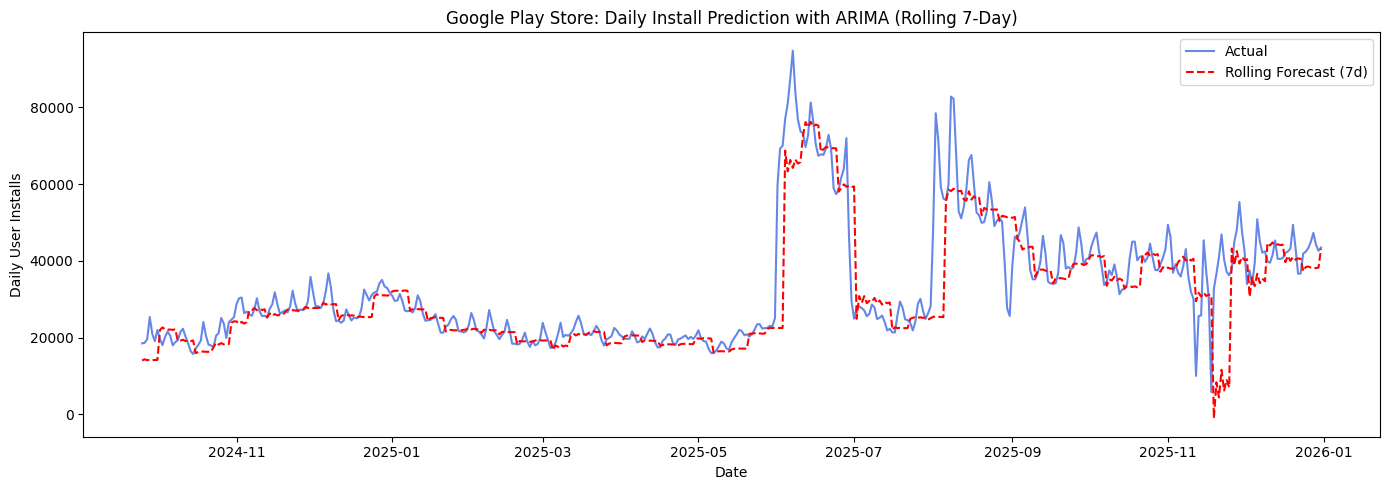

In [8]:
ROLL_PERIOD = 7  # re-fit every week, forecast 7 days ahead

# Walk-forward validation in weekly chunks:
# At each step we have *all* history up to that point, fit ARIMA,
# predict the next ROLL_PERIOD days, then reveal those actuals before
# moving to the next chunk.
history = list(train.copy())
rolling_preds = []

for start in range(0, len(test), ROLL_PERIOD):
    chunk = test.iloc[start : start + ROLL_PERIOD]   # up to 7 actual values
    steps = len(chunk)

    model_roll = ARIMA(history, order=(p, d, q))
    fit_roll   = model_roll.fit()
    yhats      = fit_roll.forecast(steps=steps)

    rolling_preds.extend(yhats)
    history.extend(chunk.tolist())   # reveal true values for next chunk

rolling_preds = pd.Series(rolling_preds, index=test.index)

rmse = np.sqrt(mean_squared_error(test, rolling_preds))
mae  = mean_absolute_error(test, rolling_preds)

print("-" * 30)
print("ARIMA ROLLING FORECAST RESULTS")
print(f"  (re-fit every {ROLL_PERIOD} days)")
print("-" * 30)
print(f"RMSE: {rmse:.2f} installs")
print(f"MAE:  {mae:.2f} installs")
print("-" * 30)

plt.figure(figsize=(14, 5))
plt.plot(test.index, test,           label="Actual",                    color="royalblue", alpha=0.8)
plt.plot(test.index, rolling_preds,  label=f"Rolling Forecast ({ROLL_PERIOD}d)", color="red", linestyle="--")
plt.title(f"Google Play Store: Daily Install Prediction with ARIMA (Rolling {ROLL_PERIOD}-Day)")
plt.xlabel("Date")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

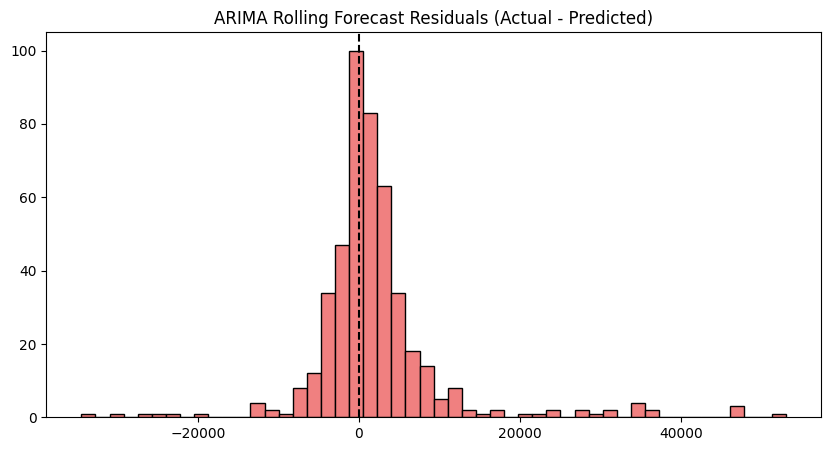

In [9]:
residuals = test - rolling_preds
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color="lightcoral", edgecolor="black")
plt.axvline(0, color="black", linestyle="--")
plt.title("ARIMA Rolling Forecast Residuals (Actual - Predicted)")
plt.show()

## Save Model

In [10]:
import pickle, json

MODEL_SAVE_PATH = "arima_model.pkl"
META_SAVE_PATH  = "arima_model_meta.json"

# Save the final fitted model (trained on full training set)
model_fit.save(MODEL_SAVE_PATH)

# Save metadata alongside
meta = {
    "model":           "ARIMA",
    "order":           list(model_auto.order),
    "target_col":      TARGET_COL,
    "train_ratio":     TRAIN_RATIO,
    "forecast_type":   "rolling_nstep",
    "roll_period_days": ROLL_PERIOD,
    "train_start":     str(train_df.index[0].date()),
    "train_end":       str(train_df.index[-1].date()),
    "test_start":      str(test_df.index[0].date()),
    "test_end":        str(test_df.index[-1].date()),
    "rmse": round(rmse, 4),
    "mae":  round(mae, 4),
}
with open(META_SAVE_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved    → {MODEL_SAVE_PATH}")
print(f"Metadata saved → {META_SAVE_PATH}")

Model saved    → arima_model.pkl
Metadata saved → arima_model_meta.json
